# 03 — Forecasting Model Training & Evaluation

**Model:** LightGBM — Gradient-boosted trees using engineered lag/calendar features

**Evaluation:**
- Train/test split: last 30 days held out
- Metrics: MAE, RMSE, MAPE
- Visual comparison of forecasts vs actuals

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import lightgbm as lgb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import warnings
import os
import pickle

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3
})

FORECAST_HORIZON = 30
RANDOM_STATE = 42

In [14]:
DATA_DIR = os.path.join('..', 'Dataset')

df = pd.read_csv(
    os.path.join(DATA_DIR, 'daily_drm_keys_clean.csv'),
    parse_dates=['LogDate']
)

print(f'Loaded: {len(df)} days | {df["LogDate"].min().date()} → {df["LogDate"].max().date()}')

Loaded: 398 days | 2019-05-01 → 2020-06-01


Train: 368 days | 2019-05-01 → 2020-05-02
Test : 30 days  | 2020-05-03 → 2020-06-01


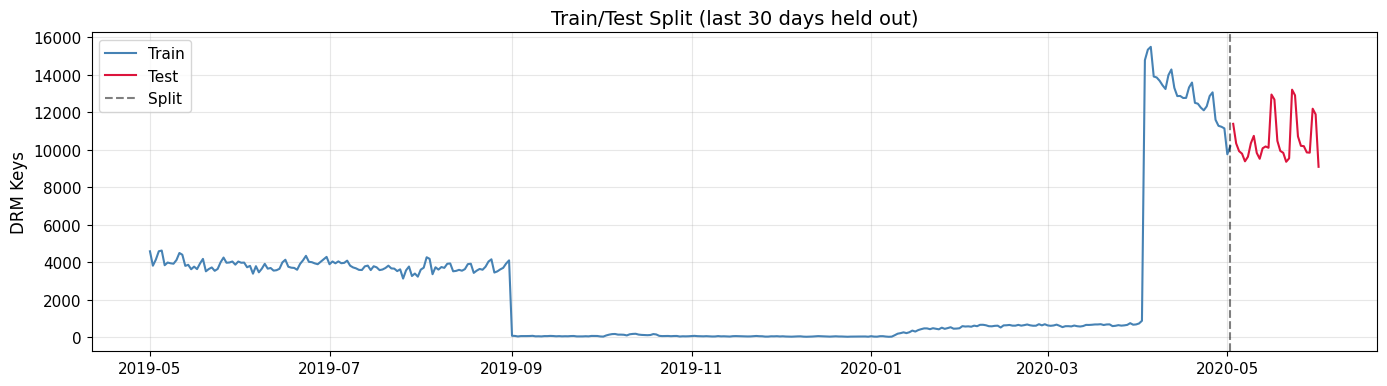

In [15]:
split_date = df['LogDate'].max() - pd.Timedelta(days=FORECAST_HORIZON)

df_train = df[df['LogDate'] <= split_date].copy()
df_test  = df[df['LogDate'] > split_date].copy()

print(f'Train: {len(df_train)} days | {df_train["LogDate"].min().date()} → {df_train["LogDate"].max().date()}')
print(f'Test : {len(df_test)} days  | {df_test["LogDate"].min().date()} → {df_test["LogDate"].max().date()}')

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train['LogDate'], df_train['Total_Daily_Keys'], label='Train', color='steelblue')
ax.plot(df_test['LogDate'], df_test['Total_Daily_Keys'], label='Test', color='crimson')
ax.axvline(split_date, color='black', linestyle='--', alpha=0.5, label='Split')
ax.set_title(f'Train/Test Split (last {FORECAST_HORIZON} days held out)')
ax.set_ylabel('DRM Keys')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
FEATURES = [
    'DayOfWeek', 'IsWeekend', 'DayOfMonth', 'WeekOfYear',
    'Month', 'Quarter', 'IsMonthStart', 'IsMonthEnd',
    'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30',
    'MA_7', 'MA_14', 'MA_30', 'Std_7',
    'WoW_Change', 'WoW_Change_Pct'
]
TARGET = 'Total_Daily_Keys'

df_model = df.dropna(subset=FEATURES).copy()

train_mask = df_model['LogDate'] <= split_date
X_train = df_model.loc[train_mask, FEATURES]
y_train = df_model.loc[train_mask, TARGET]
X_test  = df_model.loc[~train_mask, FEATURES]
y_test  = df_model.loc[~train_mask, TARGET]
test_dates = df_model.loc[~train_mask, 'LogDate'].values

print(f'Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(FEATURES)}')

Train: 338 | Test: 30 | Features: 18


In [17]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': RANDOM_STATE,
    'verbose': -1
}

train_set = lgb.Dataset(X_train, y_train)
val_set   = lgb.Dataset(X_test, y_test, reference=train_set)

model_lgb = lgb.train(
    params,
    train_set,
    num_boost_round=1000,
    valid_sets=[train_set, val_set],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f'Best iteration: {model_lgb.best_iteration}')

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 429.625	valid's rmse: 1942.89


[200]	train's rmse: 316.103	valid's rmse: 1862.2
[300]	train's rmse: 245.103	valid's rmse: 1829.77
[400]	train's rmse: 194.117	valid's rmse: 1790.01
[500]	train's rmse: 156.265	valid's rmse: 1709.25
[600]	train's rmse: 126.29	valid's rmse: 1656.87
[700]	train's rmse: 101.967	valid's rmse: 1616.63
[800]	train's rmse: 81.3452	valid's rmse: 1578.01
[900]	train's rmse: 65.8218	valid's rmse: 1547.28
[1000]	train's rmse: 51.5584	valid's rmse: 1537.78
Did not meet early stopping. Best iteration is:
[994]	train's rmse: 52.4408	valid's rmse: 1537.55
Best iteration: 994


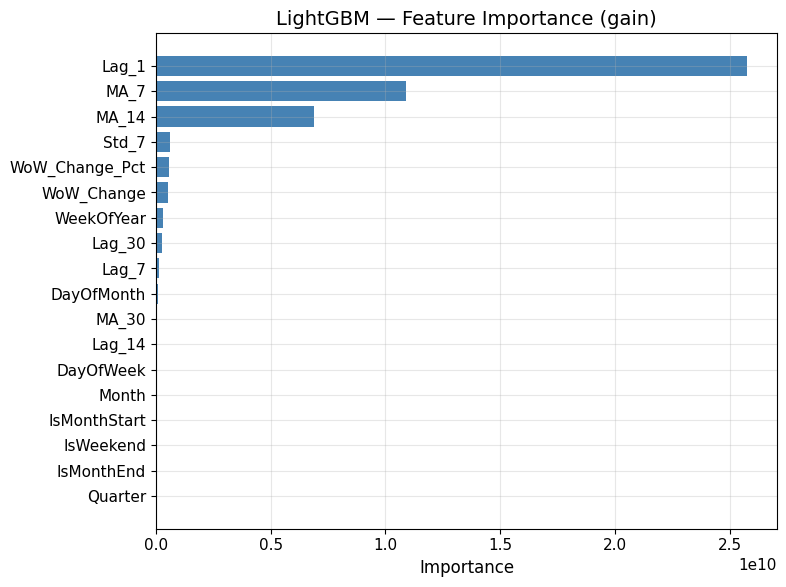

In [18]:
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model_lgb.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance['Feature'], importance['Importance'], color='steelblue')
ax.set_title('LightGBM — Feature Importance (gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

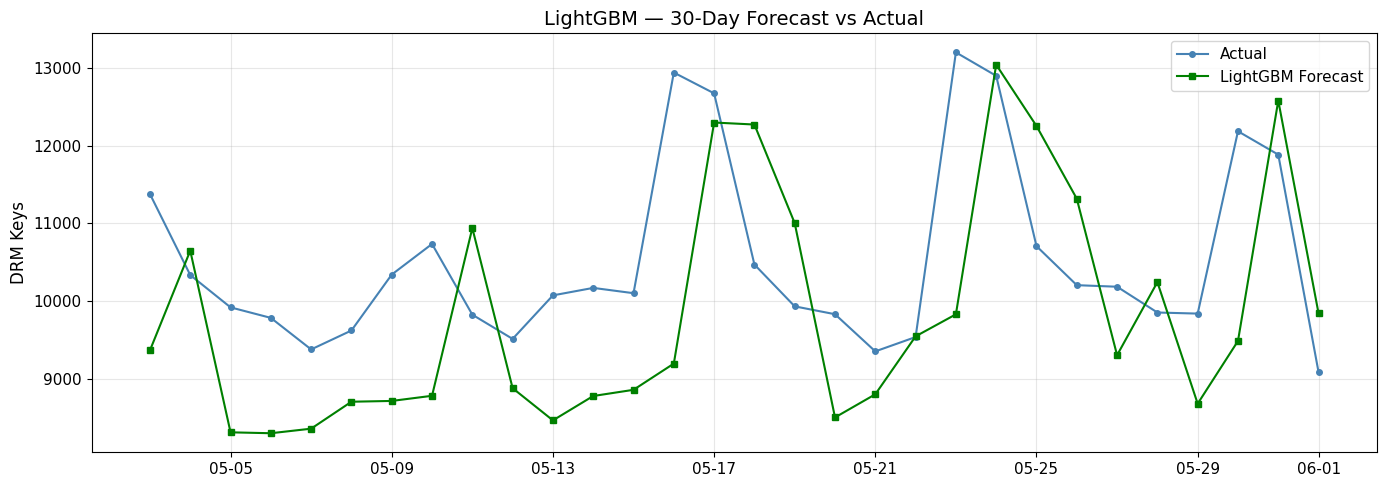

In [19]:
pred_lgb = model_lgb.predict(X_test)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, y_test.values, 'o-', label='Actual', color='steelblue', markersize=4)
ax.plot(test_dates, pred_lgb, 's-', label='LightGBM Forecast', color='green', markersize=4)
ax.set_title(f'LightGBM — {FORECAST_HORIZON}-Day Forecast vs Actual')
ax.set_ylabel('DRM Keys')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

In [20]:
mae  = mean_absolute_error(y_test, pred_lgb)
rmse = np.sqrt(mean_squared_error(y_test, pred_lgb))
mape = mean_absolute_percentage_error(y_test, pred_lgb) * 100

results = pd.DataFrame([{
    'Model': 'LightGBM',
    'MAE': round(mae, 1),
    'RMSE': round(rmse, 1),
    'MAPE (%)': round(mape, 2)
}])

display(results)

,Model,MAE,RMSE,MAPE (%)
0,LightGBM,1282.5,1537.5,11.92


In [22]:
X_full = df_model[FEATURES]
y_full = df_model[TARGET]

full_set = lgb.Dataset(X_full, y_full)

model_lgb_final = lgb.train(
    params,
    full_set,
    num_boost_round=model_lgb.best_iteration
)

last_date = df['LogDate'].max()

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame({'LogDate': future_dates})
future_df['DayOfWeek']   = future_df['LogDate'].dt.dayofweek
future_df['IsWeekend']   = (future_df['DayOfWeek'] >= 5).astype(int)
future_df['DayOfMonth']  = future_df['LogDate'].dt.day
future_df['WeekOfYear']  = future_df['LogDate'].dt.isocalendar().week.astype(int)
future_df['Month']       = future_df['LogDate'].dt.month
future_df['Quarter']     = future_df['LogDate'].dt.quarter
future_df['IsMonthStart'] = future_df['LogDate'].dt.is_month_start.astype(int)
future_df['IsMonthEnd']  = future_df['LogDate'].dt.is_month_end.astype(int)

recent = df_model[TARGET].tail(30).values
preds = np.array([])

for i in range(30):
    all_vals = np.concatenate([recent, preds]) if len(preds) > 0 else recent.copy()
    idx = future_df.index[i]
    future_df.loc[idx, 'Lag_1']  = all_vals[-1]
    future_df.loc[idx, 'Lag_7']  = all_vals[-7]
    future_df.loc[idx, 'Lag_14'] = all_vals[-14]
    future_df.loc[idx, 'Lag_30'] = all_vals[-30]
    future_df.loc[idx, 'MA_7']   = all_vals[-7:].mean()
    future_df.loc[idx, 'MA_14']  = all_vals[-14:].mean()
    future_df.loc[idx, 'MA_30']  = all_vals[-30:].mean()
    future_df.loc[idx, 'Std_7']  = all_vals[-7:].std()
    wow_change = all_vals[-1] - all_vals[-7]
    future_df.loc[idx, 'WoW_Change'] = wow_change
    future_df.loc[idx, 'WoW_Change_Pct'] = (wow_change / all_vals[-7] * 100) if all_vals[-7] != 0 else 0

    pred_i = model_lgb_final.predict(future_df.loc[[idx], FEATURES])[0]
    preds = np.append(preds, pred_i)

future_df['Forecast'] = preds.round(0).astype(int)

forecast_future = future_df[['LogDate', 'Forecast']].rename(columns={'LogDate': 'Date'})

print(f'30-day forecast: {forecast_future["Date"].min().date()} → {forecast_future["Date"].max().date()}')
display(forecast_future)

30-day forecast: 2020-06-02 → 2020-07-01


,Date,Forecast
0,2020-06-02,7638
1,2020-06-03,7074
2,2020-06-04,8224
3,2020-06-05,8625
4,2020-06-06,9584
5,2020-06-07,9982
6,2020-06-08,9518
7,2020-06-09,10016
8,2020-06-10,10147
9,2020-06-11,10086


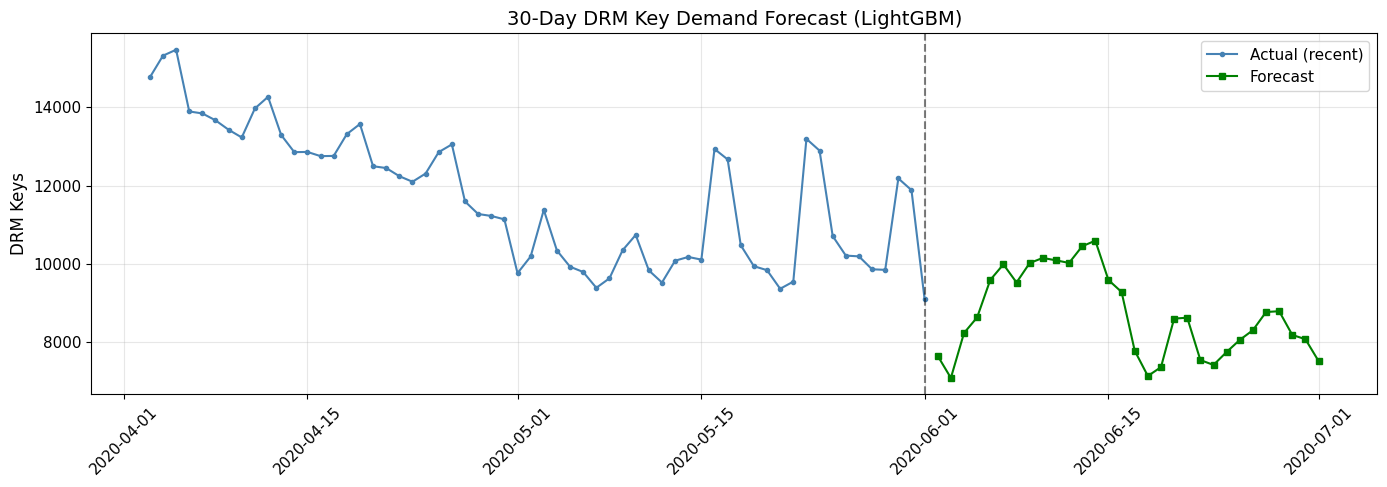

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))

recent = df.tail(60)
ax.plot(recent['LogDate'], recent['Total_Daily_Keys'], 'o-', label='Actual (recent)', color='steelblue', markersize=3)
ax.plot(forecast_future['Date'], forecast_future['Forecast'], 's-', label='Forecast', color='green', markersize=4)
ax.axvline(last_date, color='black', linestyle='--', alpha=0.5)

ax.set_title('30-Day DRM Key Demand Forecast (LightGBM)')
ax.set_ylabel('DRM Keys')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()